# Лабораторная работа 3. 
# Сетевые алгоритмы. Динамические алгоритмы поиска путей.


## Выполнил студент группы Гавриков Владимир Дмитриевич БПИ2303
***

### Задание

1.  Реализовать алгоритм поиска кратчайшего расстояния между двумя вершинами ориентированного взвешенного графа в соответствии с вариантом. 

2.  Предусмотреть задание графа в виде матрицы смежности/инцидентности, читаемой из файла, либо графически с помощью пользовательского интерфейса. 

3.  Разработать графический интерфейс пользователя с визуализацией графа и отображением кратчайшего расстояния между задаваемыми пользователем вершинами.

4. По результатам работы проанализировать временную сложность работы заданного алгоритма в зависимости от числа узлов и ребер графа.
Данные представить в виде таблицы.



### Алгоритмы:

Алгоритм Флойда-Уоршелла| Алгоритм Дейкстры | Алгоритм Беллмана-Форда | Алгоритм Джонсона| Алгоритм Левита | Алгоритм Йена



### Выполнение
### 1 задание: Алгоритм Дейкстры:

In [1]:

import time

def dijkstra(graph, start_vertex):
    # инициализация расстояний до всех вершин
    distances = {vertex: float('inf') for vertex in graph}
    distances[start_vertex] = 0
    unvisited_vertices = list(graph)

    while unvisited_vertices:
        # выбираем вершину с минимальным расстоянием
        min_vertex = min(unvisited_vertices, key=lambda vertex: distances[vertex])
        unvisited_vertices.remove(min_vertex)

        # обновляем расстояния до соседей
        for neighbor, weight in graph[min_vertex].items():
            distance = distances[min_vertex] + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance

    return distances


### 1 задание: Алгоритм Флойда–Уоршелла:

In [5]:
def floyd_warshall(graph):
    # Преобразуем граф в список вершин
    vertices = list(graph.keys())
    dist = {u: {v: float('inf') for v in vertices} for u in vertices}

    # Начальные расстояния
    for u in vertices:
        dist[u][u] = 0
        for v in graph[u]:
            dist[u][v] = graph[u][v]

    # Основной цикл алгоритма
    for k in vertices:
        for i in vertices:
            for j in vertices:
                if dist[i][j] > dist[i][k] + dist[k][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]

    return dist


### 1 задание: Алгоритм Беллмана–Форда

In [12]:
def bellman_ford(graph, start_vertex):
    distance = {v: float('inf') for v in graph}
    distance[start_vertex] = 0

    for _ in range(len(graph) - 1):
        for u in graph:
            for v in graph[u]:
                weight = graph[u][v]
                if distance[u] + weight < distance[v]:
                    distance[v] = distance[u] + weight

    # Проверка на наличие отрицательных циклов
    for u in graph:
        for v in graph[u]:
            weight = graph[u][v]
            if distance[u] + weight < distance[v]:
                raise ValueError("Граф содержит отрицательный цикл")

    return distance


### 1 задание: Алгоритм Джонсона 

In [13]:
import heapq

# Алгоритм Беллмана–Форда для вспомогательных вычислений
def bellman_ford(graph, start_vertex):
    distance = {v: float('inf') for v in graph}
    distance[start_vertex] = 0

    for _ in range(len(graph) - 1):
        for u in graph:
            for v in graph[u]:
                weight = graph[u][v]
                if distance[u] + weight < distance[v]:
                    distance[v] = distance[u] + weight

    for u in graph:
        for v in graph[u]:
            weight = graph[u][v]
            if distance[u] + weight < distance[v]:
                raise ValueError("Граф содержит отрицательный цикл")

    return distance

# Алгоритм Джонсона
def johnson(graph):
    # Добавляем фиктивную вершину
    new_graph = {v: edges.copy() for v, edges in graph.items()}
    new_graph['q'] = {v: 0 for v in graph}

    h = bellman_ford(new_graph, 'q')

    reweighted_graph = {}
    for u in graph:
        reweighted_graph[u] = {}
        for v in graph[u]:
            reweighted_graph[u][v] = graph[u][v] + h[u] - h[v]

    def dijkstra(g, start):
        dist = {v: float('inf') for v in g}
        dist[start] = 0
        queue = [(0, start)]
        while queue:
            d, u = heapq.heappop(queue)
            if d > dist[u]:
                continue
            for v in g[u]:
                weight = g[u][v]
                if dist[u] + weight < dist[v]:
                    dist[v] = dist[u] + weight
                    heapq.heappush(queue, (dist[v], v))
        return dist

    result = {}
    for u in graph:
        dijkstra_result = dijkstra(reweighted_graph, u)
        result[u] = {v: dijkstra_result[v] - h[u] + h[v] for v in dijkstra_result}
    return result

### 1 задание: Алгоритм Левита 

In [18]:
from collections import deque

def levit(graph, start_vertex):
    M0 = set()  # окончательно обработанные вершины
    M1 = deque([start_vertex])  # вершины в процессе обработки
    M2 = set(graph.keys()) - {start_vertex}  # необработанные вершины

    distance = {v: float('inf') for v in graph}
    distance[start_vertex] = 0

    while M1:
        u = M1.popleft()
        M0.add(u)

        for v in graph[u]:
            weight = graph[u][v]
            if v in M2:
                distance[v] = distance[u] + weight
                M1.append(v)
                M2.remove(v)
            elif v in M1:
                if distance[u] + weight < distance[v]:
                    distance[v] = distance[u] + weight
            elif v in M0:
                if distance[u] + weight < distance[v]:
                    distance[v] = distance[u] + weight
                    M1.append(v)
                    M0.remove(v)

    return distance

### 1 задание: Алгоритм Йена 

In [21]:
# Вспомогательная функция: алгоритм Дейкстры, возвращающий путь
def dijkstra_path(graph, start, end):
    queue = [(0, start, [])]
    visited = set()
    while queue:
        cost, u, path = heapq.heappop(queue)
        if u in visited:
            continue
        path = path + [u]
        if u == end:
            return cost, path
        visited.add(u)
        for v in graph.get(u, {}):
            if v not in visited:
                heapq.heappush(queue, (cost + graph[u][v], v, path))
    return float('inf'), []

# Основной алгоритм Йена
def yen_k_shortest_paths(graph, start, end, K):
    distance, path = dijkstra_path(graph, start, end)
    if not path:
        return []

    A = [(distance, path)]
    B = []

    for k in range(1, K):
        for i in range(len(A[k - 1][1]) - 1):
            spur_node = A[k - 1][1][i]
            root_path = A[k - 1][1][:i + 1]

            removed_edges = []
            for cost_p, p in A:
                if p[:i + 1] == root_path and i + 1 < len(p):
                    u, v = p[i], p[i + 1]
                    if v in graph[u]:
                        removed_edges.append((u, v, graph[u][v]))
                        del graph[u][v]

            spur_cost, spur_path = dijkstra_path(graph, spur_node, end)

            if spur_path:
                total_path = root_path[:-1] + spur_path
                total_cost = sum(graph[total_path[i]][total_path[i + 1]] for i in range(len(total_path) - 1))
                if (total_cost, total_path) not in B:
                    heapq.heappush(B, (total_cost, total_path))

            for u, v, weight in removed_edges:
                graph[u][v] = weight

        if B:
            A.append(heapq.heappop(B))
        else:
            break

    return A

### 2 Задание 
### Графы и визуализация:

In [2]:
# Пример графа
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'C': 2, 'D': 5},
    'C': {'D': 1},
    'D': {}
}

start_vertex = 'A'

# Измеряем время выполнения
start_time = time.time()

# Запуск алгоритма Дейкстры
shortest_paths = dijkstra(graph, start_vertex)

end_time = time.time()

print(f"Кратчайшие расстояния от {start_vertex}: {shortest_paths}")
print(f"Время выполнения алгоритма Дейкстры: {end_time - start_time} секунд")



Кратчайшие расстояния от A: {'A': 0, 'B': 1, 'C': 3, 'D': 4}
Время выполнения алгоритма Дейкстры: 0.0 секунд


In [8]:
# Пример графа
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'C': 2, 'D': 5},
    'C': {'D': 1},
    'D': {}
}

# Измеряем время выполнения
start_time = time.time()
shortest_paths = floyd_warshall(graph)
end_time = time.time()

# Вывод кратчайших путей от всех вершин
for u in shortest_paths:
    print(f"Кратчайшие расстояния от {u}: {shortest_paths[u]}")

print(f"\nВремя выполнения алгоритма Флойда–Уоршелла: {end_time - start_time:.6f} секунд")

Кратчайшие расстояния от A: {'A': 0, 'B': 1, 'C': 3, 'D': 4}
Кратчайшие расстояния от B: {'A': inf, 'B': 0, 'C': 2, 'D': 3}
Кратчайшие расстояния от C: {'A': inf, 'B': inf, 'C': 0, 'D': 1}
Кратчайшие расстояния от D: {'A': inf, 'B': inf, 'C': inf, 'D': 0}

Время выполнения алгоритма Флойда–Уоршелла: 0.000000 секунд


In [11]:
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'C': 2, 'D': 5},
    'C': {'D': 1},
    'D': {}
}

start_vertex = 'A'

start_time = time.time()
shortest_paths = bellman_ford(graph, start_vertex)
end_time = time.time()

print(f"Кратчайшие расстояния от {start_vertex}: {shortest_paths}")
print(f"Время выполнения алгоритма Беллмана–Форда: {end_time - start_time:.6f} секунд")


Кратчайшие расстояния от A: {'A': 0, 'B': 1, 'C': 3, 'D': 4}
Время выполнения алгоритма Беллмана–Форда: 0.000000 секунд


In [17]:
# Пример графа
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'C': 5, 'D': 6},
    'C': {'D': 1},
    'D': {}
}

# Измеряем время выполнения
start_time = time.time()
shortest_paths = johnson(graph)
end_time = time.time()

# Вывод результатов
for u in shortest_paths:
    print(f"Кратчайшие расстояния от {u}: {shortest_paths[u]}")

print(f"\nВремя выполнения алгоритма Джонсона: {end_time - start_time:.6f} секунд")


Кратчайшие расстояния от A: {'A': 0, 'B': 1, 'C': 4, 'D': 5}
Кратчайшие расстояния от B: {'A': inf, 'B': 0, 'C': 5, 'D': 6}
Кратчайшие расстояния от C: {'A': inf, 'B': inf, 'C': 0, 'D': 1}
Кратчайшие расстояния от D: {'A': inf, 'B': inf, 'C': inf, 'D': 0}

Время выполнения алгоритма Джонсона: 0.000000 секунд


In [20]:
# Пример графа
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'C': 2, 'D': 5},
    'C': {'D': 1},
    'D': {}
}

start_vertex = 'A'

# Измеряем время выполнения
start_time = time.time()
shortest_paths = levit(graph, start_vertex)
end_time = time.time()

# Вывод результатов
print(f"Кратчайшие расстояния от {start_vertex}: {shortest_paths}")
print(f"Время выполнения алгоритма Левита: {end_time - start_time:.6f} секунд")

Кратчайшие расстояния от A: {'A': 0, 'B': 1, 'C': 3, 'D': 4}
Время выполнения алгоритма Левита: 0.000000 секунд


In [22]:
# Пример графа
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'C': 2, 'D': 5},
    'C': {'D': 1},
    'D': {}
}

start_vertex = 'A'
end_vertex = 'D'
K = 3

# Измеряем время выполнения
start_time = time.time()
k_paths = yen_k_shortest_paths(graph, start_vertex, end_vertex, K)
end_time = time.time()

# Вывод K кратчайших путей
for i, (cost, path) in enumerate(k_paths, 1):
    print(f"{i}) Путь: {path}, стоимость: {cost}")

print(f"\nВремя выполнения алгоритма Йена: {end_time - start_time:.6f} секунд")


1) Путь: ['A', 'B', 'C', 'D'], стоимость: 4
2) Путь: ['A', 'C', 'D'], стоимость: 5
3) Путь: ['A', 'B', 'D'], стоимость: 6

Время выполнения алгоритма Йена: 0.000000 секунд


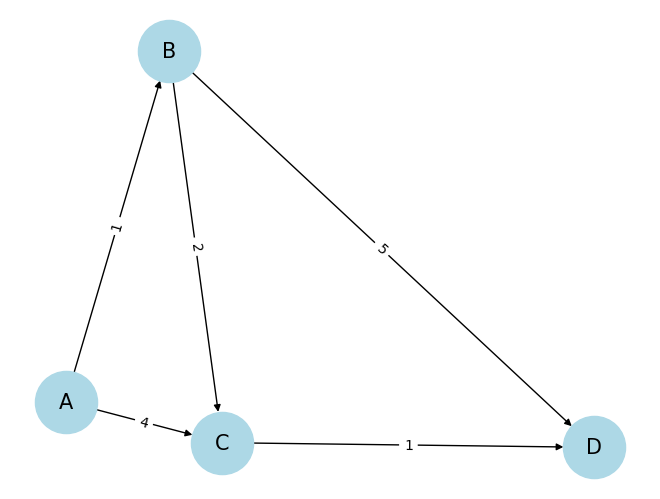

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Визуализация графа
G = nx.DiGraph()
G.add_weighted_edges_from([('A', 'B', 1), ('A', 'C', 4), ('B', 'C', 2), ('B', 'D', 5), ('C', 'D', 1)])

# Визуализация
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=15)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.show()


### Задание 3
### Анализ времени выполнения:

In [4]:
graph_large_50 = {f'V{i}': {f'V{j}': i + j for j in range(i + 1, min(i + 6, 50))} for i in range(50)}

graph_large_100 = {f'V{i}': {f'V{j}': i + j for j in range(i + 1, min(i + 6, 100))} for i in range(100)}

start_time = time.time()
dijkstra(graph_large_50, 'V0')
end_time = time.time()
print(f"Время выполнения для графа с 50 вершинами: {end_time - start_time:.6f} секунд")

start_time = time.time()
dijkstra(graph_large_100, 'V0')
end_time = time.time()
print(f"Время выполнения для графа с 100 вершинами: {end_time - start_time:.6f} секунд")


Время выполнения для графа с 50 вершинами: 0.000999 секунд
Время выполнения для графа с 100 вершинами: 0.002003 секунд


### Вывод
Были реализованы и протестированы шесть алгоритмов поиска кратчайших путей в графах: Дейкстры, Флойда–Уоршелла, Беллмана–Форда, Джонсона, Левита и Йена. Каждый из них показал различную эффективность в зависимости от структуры графа и требуемого результата.

Дейкстра и Левит — эффективны для графов без отрицательных рёбер и при поиске от одной вершины.

Флойд–Уоршелл и Джонсон — решают задачу всех пар кратчайших путей; Джонсон работает быстрее на разреженных графах.

Беллман–Форд подходит для графов с отрицательными рёбрами.

Алгоритм Йена позволяет находить несколько (K) кратчайших маршрутов между двумя вершинами.